In [10]:
import torch
from tqdm import tqdm
from scipy.ndimage.filters import gaussian_filter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import pyplot as plt
import torch
from torch.utils.data.sampler import Sampler
from torchvision import transforms
from PIL import Image
import time
from IPython.display import clear_output
from einops import rearrange
from affex.data.utils import BatchKeys
from affex.utils.utils import ResultDict, to_device

import torch.nn.functional as F


import lovely_tensors as lt
lt.monkey_patch()

# Dummy class to store arguments
class Dummy():
    pass


# Function that opens image from disk, normalizes it and converts to tensor
read_tensor = transforms.Compose([
    lambda x: Image.open(x),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
    lambda x: torch.unsqueeze(x, 0)
])


# Plots image from tensor
def tensor_imshow(inp, title=None, **kwargs):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    # Mean and std for ImageNet
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp, **kwargs)
    if title is not None:
        plt.title(title)


# Image preprocessing function
preprocess = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                # Normalization for ImageNet
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
            ])


# Sampler for pytorch loader. Given range r loader will only
# return dataset[r] instead of whole dataset.
class RangeSampler(Sampler):
    def __init__(self, r):
        self.r = r

    def __iter__(self):
        return iter(self.r)

    def __len__(self):
        return len(self.r)


In [11]:
import copy
from affex.data import get_dataloaders


PROMPT_IMAGES = [
    # 'frame0009_2.png',
    'frame0021_2.png',
    "frame0033_3.png",
    'frame0034_1.png',
    'frame0048_0.png',
]

PASCAL_NAME = "val_pascal5i"
PASCAL_PARAMS = {
    "name": "pascal",
    "data_dir": "data/pascal",
    "split": "val",
    "val_fold_idx": 3,
    "n_folds": 4,
    "n_shots": 2,
    "n_ways": 1,
    "do_subsample": False,
    "val_num_samples": 100,
    "ignore_borders": True,
}

parameters = {
    "dataloader": {
        "num_workers": 0,
        "possible_batch_example_nums": [[1, 2, 4]],
        "val_possible_batch_example_nums": [[1, 1]],
        "prompt_types": ["mask"],
        "prompt_choice_level": ["episode"],
        "val_prompt_types": ["mask"],
        },
    "dataset": {
        "preprocess": {
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225],
            "image_size": 384,
        },
        "datasets": {
            PASCAL_NAME: PASCAL_PARAMS,
        },
    },
    "model": {
        "name": "dcama",
        "backbone": "swin",
        # "backbone_checkpoint": "checkpoints/swin_base_patch4_window12_384.pth",
        "model_checkpoint": "checkpoints/swin_fold0_pascal_modcross_soft.pt",
        # 'model_checkpoint': "checkpoints/f4z7ghu7.pt",
        "concat_support": True,
        "image_size": 384,
    }
}

def get_data(n_ways, n_shots, image_size):
    parameters["dataset"]["datasets"][PASCAL_NAME]["n_ways"] = n_ways
    parameters["dataset"]["datasets"][PASCAL_NAME]["n_shots"] = n_shots
    parameters["dataset"]["datasets"][PASCAL_NAME]["image_size"] = image_size
    parameters["dataset"]["preprocess"]["image_size"] = image_size
    
    _, val, _ = get_dataloaders(
        copy.deepcopy(parameters["dataset"]),
        copy.deepcopy(parameters["dataloader"]),
        num_processes=1,
    )
    return val[PASCAL_NAME]

In [12]:
from affex.models import build_model_preconfigured

model = "dcama"
device = "cuda"
n_shots = 2
n_ways = 1
use_pe = True

model, image_size = build_model_preconfigured(model_name=model, use_pe=use_pe, n_shots=n_shots)
model.to(device)
model.eval()

Using pe from state_dict


DCAMAMultiClass(
  (feature_extractor): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0): BasicLayer(
        dim=128, input_resolution=(96, 96), depth=2
        (blocks): ModuleList(
          (0): SwinTransformerBlock(
            dim=128, input_resolution=(96, 96), num_heads=4, window_size=12, shift_size=0, mlp_ratio=4.0
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              dim=128, window_size=(12, 12), num_heads=4
              (qkv): Linear(in_features=128, out_features=384, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=128, out_features=128, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax)

In [13]:
data = get_data(n_ways, n_shots, image_size)

WARNING [05-28 17:51:14] [pascal] load_embeddings is not specified. Assuming load_embeddings=False.


Loading image filenames from val...


Loading annotations...: 100%|██████████| 1449/1449 [00:01<00:00, 1082.59it/s]


In [14]:
batch = next(iter(data))

In [15]:
from affex.substitution import Substitutor


batch, dataset_name  = batch

substitutor = Substitutor(substitute=False)
substitutor.reset(batch=batch)
batch = next(substitutor)

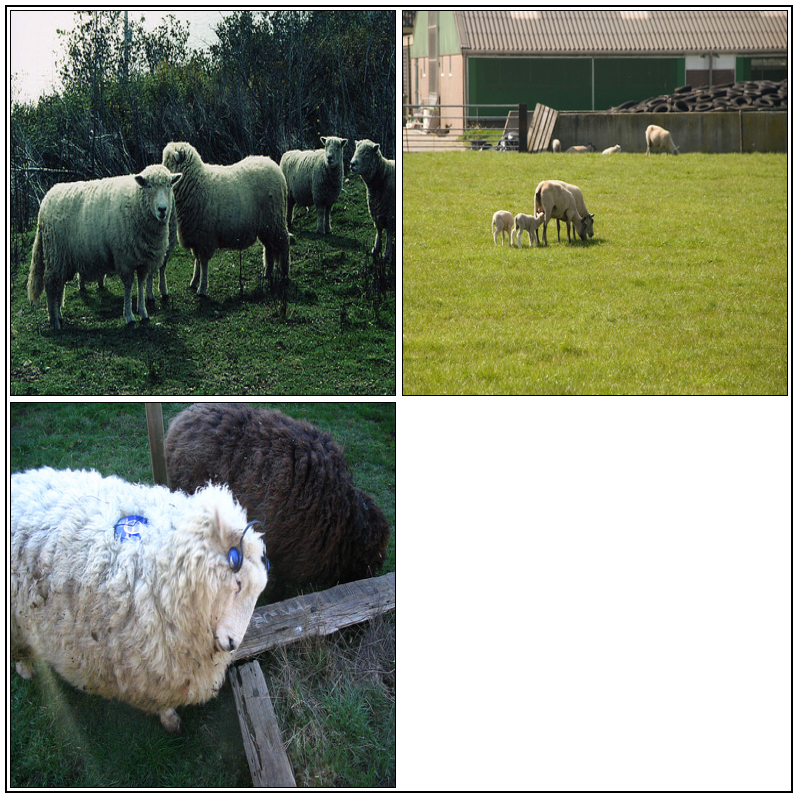

In [16]:
from affex.data.utils import BatchKeys
from affex.utils.segmentation import unnormalize

input_dict, gt = batch
unnormalize(input_dict[BatchKeys.IMAGES]).rgb

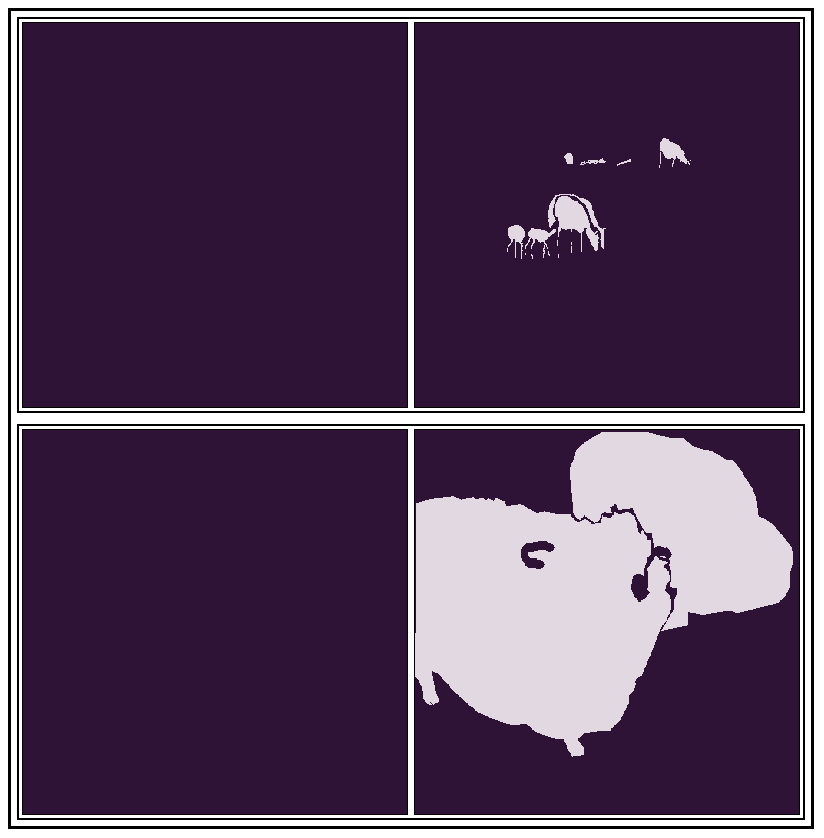

In [17]:
input_dict[BatchKeys.PROMPT_MASKS].chans

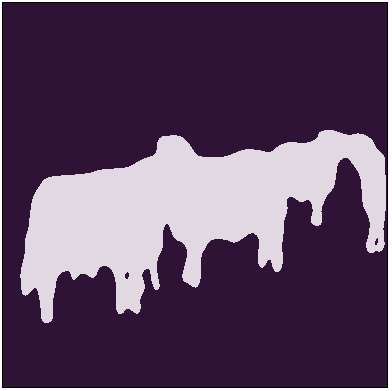

In [32]:
from affex.utils.utils import ResultDict

import torch.nn.functional as F

input_dict = to_device(input_dict, device)
target_shape = input_dict[BatchKeys.IMAGES][:, 0].shape[2:]

with torch.no_grad():
    result = model(input_dict, postprocess=False)

logits = F.interpolate(
            result[ResultDict.LOGITS],
            size=target_shape,
            mode="bilinear",
            align_corners=False,
            antialias=False,
        ).argmax(dim=1)
explanation_mask = F.one_hot(logits, num_classes=n_ways+1).permute(0, 3, 1, 2)[0].bool()[1]
logits.chans

In [83]:
import math
from typing import Dict, List, Tuple
from einops import rearrange
import torch
import torch.nn as nn

from captum.attr import IntegratedGradients, Saliency, LayerGradCam


GRADIENT_KEYS = [
    BatchKeys.IMAGES,
    BatchKeys.PROMPT_MASKS,
]
NON_GRADIENT_KEYS = [
    BatchKeys.FLAG_MASKS,
    BatchKeys.FLAG_EXAMPLES,
    BatchKeys.DIMS,
]

class LamLayerGradCam(LayerGradCam):
    def attribute(self, *args, **kwargs):
        print(args)
        inputs = args[0]
        b, m, c, h, w = inputs[0].shape
        attrs = super().attribute(*args, **kwargs)
        size = int(math.sqrt(attrs[0].shape[0]))
        print(attrs)
        return (rearrange(attrs.sum(dim=-1), " b (h w) -> b h w", h=size),)

class TraditionalExplainer(nn.Module):
    methods = {
        "integrated gradients": (IntegratedGradients, {}, {"n_steps": 100, "internal_batch_size": 1}),
        "saliency": (Saliency, {}, {}),
        "gradcam": (LamLayerGradCam, {}, {"attr_dim_summation": False}),
    }
    def __init__(self, model: nn.Module, method: str = "integrated gradients", layer: str = None):
        super(TraditionalExplainer, self).__init__()
        self.model = model
        self.explanation_mask = None
        
        method, init_kwargs, kwargs = self.methods[method]
        if method == LamLayerGradCam:
            init_kwargs["layer"] = layer
        self.method = method(self, **init_kwargs)
        self.method_kwargs = kwargs

    def prepare(self, explanation_mask):
        self.explanation_mask = explanation_mask

    def forward(
        self, *batched_input_tuple: Tuple[torch.Tensor, ...]
    ) -> List[Dict[str, torch.Tensor]]:

        tuple_mapping = batched_input_tuple[-1]

        # Prepare batched_input in the format expected by self._forward
        batched_input = {
            key: batched_input_tuple[value] for key, value in tuple_mapping.items()
        }

        results = self.model(batched_input, postprocess=False)
        logits = results[ResultDict.LOGITS]
        out = logits[:, :, self.explanation_mask].mean(dim=-1)
        return out

    def explain(self, batch, explanation_mask, target):
        self.prepare(explanation_mask)
        # Get a tuple from the batch
        main_input = {key: batch[key] for key in batch.keys() if key in GRADIENT_KEYS}

        additional_input = {
            key: batch[key] for key in batch.keys() if key in NON_GRADIENT_KEYS
        }
        tuple_mapping = {key: i for i, key in enumerate(main_input.keys())} | {
            key: i + len(main_input) for i, key in enumerate(additional_input.keys())
        }
        main_input = tuple(main_input.values())
        additional_input = tuple(additional_input.values())
        additional_input += (tuple_mapping,)

        attribution_tuple = self.method.attribute(
            main_input,
            additional_forward_args=additional_input,
            target=target,
            **self.method_kwargs,
        )
        return dict(zip(tuple_mapping.keys(), attribution_tuple))


In [92]:
layer = model.feature_extractor.layers[-1].blocks[-1].mlp.fc2
explainer = TraditionalExplainer(model)

In [85]:
overall_explanation = explainer.explain(input_dict, explanation_mask, target=1)

((tensor[1, 2, 2, 384, 384] n=589824 (2.2Mb) x∈[0., 1.000] μ=0.129 σ=0.335 cuda:0, tensor[1, 3, 3, 384, 384] n=1327104 (5.1Mb) x∈[-2.118, 2.640] μ=-0.385 σ=1.080 cuda:0),)
tensor[1, 144, 1024] n=147456 (0.6Mb) x∈[-7.092e-05, 7.964e-05] μ=5.690e-11 σ=2.959e-07 grad MulBackward0 cuda:0


In [87]:
from affex.data.utils import min_max_scale


explanation = overall_explanation[BatchKeys.IMAGES]
explanation = min_max_scale(explanation.mean(dim=2))
explanation[:, 1:].chans

KeyError: <BatchKeys.IMAGES: 'images'>

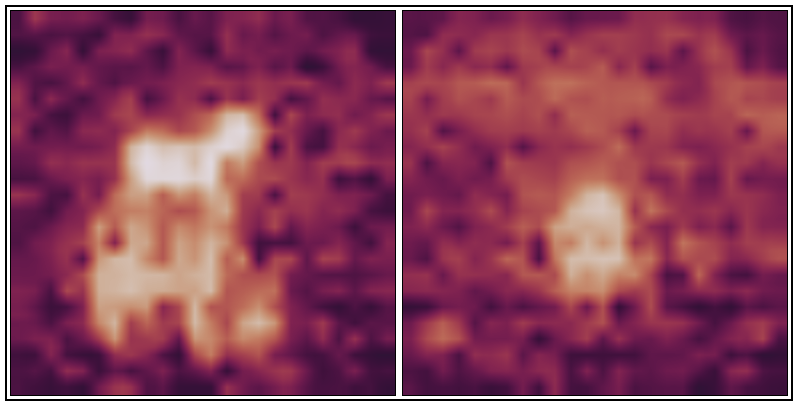

In [13]:
weighted_explanation = explanation[0][1]
weighted_explanation = rearrange(weighted_explanation, 'B H (M W) -> B M H W', W=target_shape[1], M=n_shots)
weighted_explanation.chans

In [14]:
fssmetric = FSSCausalMetric(model, 'ins', 1000, torch.zeros_like)

Inserting pixels:   1%|▏         | 4/296 [00:00<00:15, 19.19it/s]

Inserting pixels: 100%|██████████| 296/296 [00:15<00:00, 19.38it/s]

xAUC: tensor 0.956


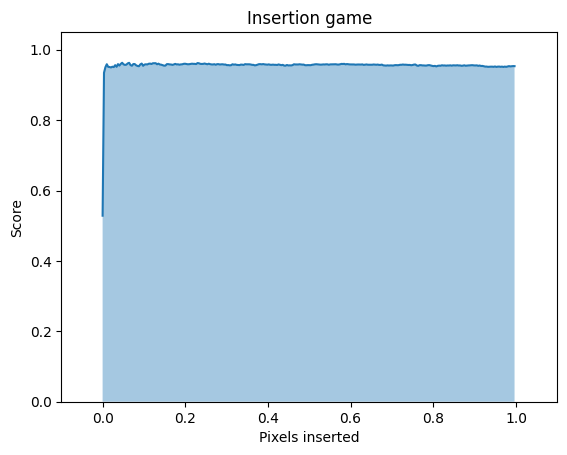

In [15]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

xauc, scores = fssmetric.evaluate(input_dict, weighted_explanation, explanation_mask[1])
batch_element = 0
print('xAUC:', xauc)
# Plot scores
plt.plot(np.arange(scores.shape[0]) / scores.shape[0], scores[:, batch_element])
plt.fill_between(np.arange(scores.shape[0]) / scores.shape[0], 0, scores[:, batch_element], alpha=0.4)
plt.xlim(-0.1, 1.1)
plt.ylim(0, 1.05)
plt.xlabel('Pixels inserted')
plt.ylabel('Score')
plt.title('Insertion game')
plt.show()

In [16]:
# for start, i, scores in fssmetric.evaluate_interactive(batch, explanation, explanation_mask):
#     print('Step {}: {}'.format(i, scores))
#     # display(start[BatchKeys.IMAGES][:, 1:].rgb)
#     ylabel = 'Pixels inserted'
#     plt.figure(figsize=(10, 5))
#     plt.subplot(121)
#     plt.title('{} {:.1f}%'.format(ylabel, 100 * i / fssmetric.n_steps))
#     plt.axis('off')

#     plt.subplot(122)
#     plt.plot(np.arange(i+1) / fssmetric.n_steps, scores[:i+1])
#     plt.xlim(-0.1, 1.1)
#     plt.ylim(0, 1.05)
#     plt.fill_between(np.arange(i+1) / fssmetric.n_steps, 0, scores[0, :i+1], alpha=0.4)
#     plt.xlabel(ylabel)
#     plt.ylabel('Score')
#     plt.show()
    
#     time.sleep(2)
#     clear_output(wait=True)